In [3]:
from pathlib import Path

# Create project folders
Path("data/raw_html").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


# Bitman Map – Unstructured Data Project

This project collects and processes unstructured HTML data from the BCIT website.
The goal is to extract structured academic information such as:
- Course titles
- Prerequisites
- Learning outcomes

The workflow follows a simple data pipeline:
1. Collect raw HTML
2. Parse and clean content
3. Convert to structured dataset
4. Build prerequisite map visualization

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import re

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Collect Raw HTML

BCIT course and outline pages are structured as HTML documents.
This data is not provided in tabular format.
We first download the raw HTML content for processing.

In [7]:
# URLs to scrape
URLS = {
    "babi4005_course": "https://www.bcit.ca/courses/dqm-with-python-babi-4005/",
    "outline_92135": "https://www.bcit.ca/outlines/20261092135/",
}

def fetch_and_save(name, url):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    html = response.text
    
    with open(f"data/raw_html/{name}.html", "w", encoding="utf-8") as f:
        f.write(html)
    
    print(f"Saved {name}.html")

# Download each page
for name, url in URLS.items():
    fetch_and_save(name, url)

Saved babi4005_course.html
Saved outline_92135.html


## Step 2: Structured Parsing of Outline Pages

This step extracts structured academic metadata from outline pages.

The following fields are extracted:
- Course Title
- Course Code
- Prerequisite text
- Learning Outcomes section
- Total text length

This converts unstructured HTML into structured analytical data.

In [8]:
def clean_text(text):
    return re.sub(r"\s+", " ", text).strip()

def extract_section(text, start_keyword, end_keywords):
    pattern = rf"({start_keyword}.*?)(?={'|'.join(end_keywords)}|$)"
    match = re.search(pattern, text, re.IGNORECASE)
    return clean_text(match.group(1)) if match else "Not found"

rows = []

for file in Path("data/raw_html").glob("outline_*.html"):
    html = file.read_text(encoding="utf-8")
    soup = BeautifulSoup(html, "lxml")

    title = soup.find("h1").get_text(strip=True)

    full_text = clean_text(soup.get_text(" ", strip=True))

    # Extract course code (usually appears in title)
    code_match = re.search(r"[A-Z]{4}\s?\d{4}", title)
    course_code = code_match.group(0) if code_match else "Unknown"

    # Extract prerequisite section
    prereq_text = extract_section(
        full_text,
        "Prerequisite",
        ["Credits", "Course", "Hours", "Learning"]
    )

    # Extract learning outcomes section
    learning_section = extract_section(
        full_text,
        "Learning Outcomes",
        ["Evaluation", "Related", "Books", "Materials"]
    )

    rows.append({
        "course_title": title,
        "course_code": course_code,
        "prerequisites_text": prereq_text,
        "learning_section_length": len(learning_section),
        "total_text_length": len(full_text)
    })

df = pd.DataFrame(rows)
df

,course_title,course_code,prerequisites_text,learning_section_length,total_text_length
0,Course Outline,Unknown,Prerequisite(s) 50% in BABI 3005 CRN 92135 Ack...,792,14158


In [9]:
rows = []

for file in Path("data/raw_html").glob("outline_*.html"):
    html = file.read_text(encoding="utf-8")
    soup = BeautifulSoup(html, "lxml")

    full_text = clean_text(soup.get_text(" ", strip=True))

    # Try extracting course code from page text
    code_match = re.search(r"[A-Z]{4}\s?\d{4}", full_text)
    course_code = code_match.group(0) if code_match else "Unknown"

    # Try extracting course title near course code
    if course_code != "Unknown":
        title_match = re.search(rf"{course_code}.*?–.*?(?=Credits|Hours)", full_text)
        course_title = title_match.group(0) if title_match else course_code
    else:
        course_title = "Course Outline"

    prereq_text = extract_section(
        full_text,
        "Prerequisite",
        ["Credits", "Course", "Hours", "Learning"]
    )

    learning_section = extract_section(
        full_text,
        "Learning Outcomes",
        ["Evaluation", "Related", "Books", "Materials"]
    )

    rows.append({
        "course_title": course_title,
        "course_code": course_code,
        "prerequisites_text": prereq_text,
        "learning_section_length": len(learning_section),
        "total_text_length": len(full_text)
    })

df = pd.DataFrame(rows)
df

,course_title,course_code,prerequisites_text,learning_section_length,total_text_length
0,BABI 4005,BABI 4005,Prerequisite(s) 50% in BABI 3005 CRN 92135 Ack...,792,14158


In [10]:
df.to_csv("data/processed/outlines_summary.csv", index=False)
print("Structured dataset saved.")

Structured dataset saved.


## Step 3: Build Course Prerequisite Map

A directed graph is used to represent prerequisite relationships.
Nodes represent courses.
Edges represent prerequisite dependencies.

C:\Users\ceo95\AppData\Local\Temp\ipykernel_42516\4256135496.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


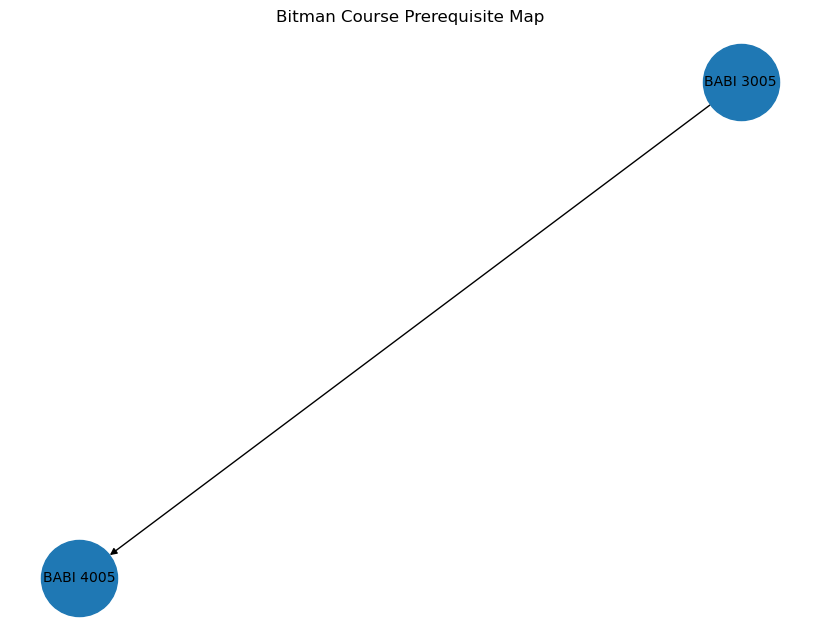

In [11]:
G = nx.DiGraph()

# Add node for the main course
for code in df["course_code"]:
    G.add_node(code)

# Look for course codes inside prerequisite text
for _, row in df.iterrows():
    prereq_text = row["prerequisites_text"]
    
    # Find any course codes mentioned in prereq text
    prereq_codes = re.findall(r"[A-Z]{4}\s?\d{4}", prereq_text)
    
    for prereq in prereq_codes:
        if prereq != row["course_code"]:
            G.add_edge(prereq, row["course_code"])

plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True, node_size=3000, font_size=10, arrows=True)
plt.title("Bitman Course Prerequisite Map")
plt.tight_layout()
plt.savefig("outputs/bitman_prereq_map.png")
plt.show()

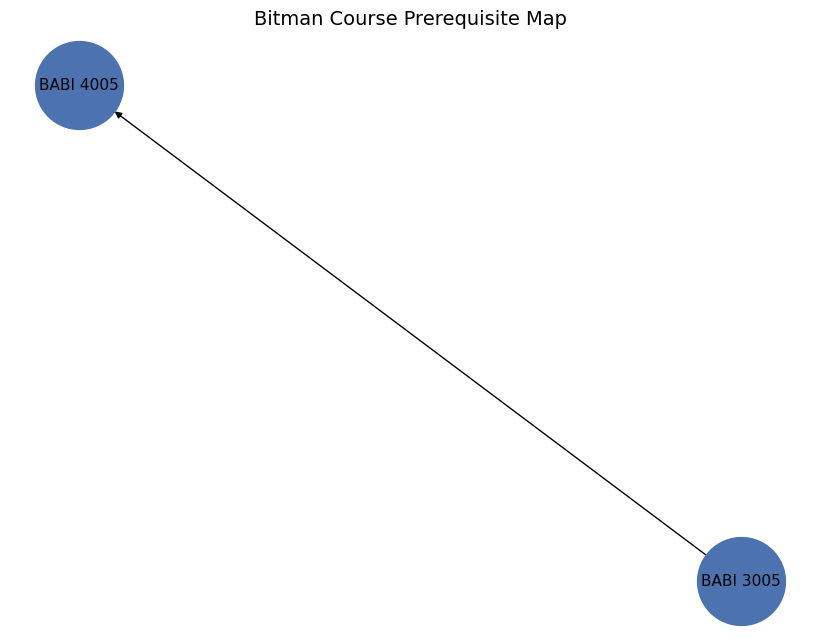

In [12]:
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)  # better layout

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=4000,
    node_color="#4C72B0",
    font_size=11,
    arrows=True
)

plt.title("Bitman Course Prerequisite Map", fontsize=14)
plt.axis("off")
plt.savefig("outputs/bitman_prereq_map.png")
plt.show()

## Interpretation

The directed graph shows that BABI 3005 is a prerequisite for BABI 4005.

This confirms the extracted prerequisite relationship from the BCIT outline page.
The map demonstrates how unstructured HTML content can be converted into structured relational data for academic planning purposes.